In [28]:
import pandas as pd
df = pd.read_excel(r'D:\\New folder (2)\\only ans.xlsx')

In [29]:
df.loc[538] = "abc"
df

,"1. In your viewpoint, what aspects of our institution should we sustain over the next two years?"
0,Placement training and providing internship op...
1,Support faculty and students in research initi...
2,Nil
3,Placements and training
4,The idea of idea factory is good that it wold ...
...,...
4458,Our institution should sustain a focus on inno...
4459,To sustain and enhance the culture at REC over...
4460,Improve the quality of teaching and training
4461,I am not sure about it.


In [12]:
df = df.dropna()

In [16]:
input=""
for i in  df['1. In your viewpoint, what aspects of our institution should we sustain over the next two years?']:
    input+=str(i)

In [17]:
ins1 =input[:5000]
ins2 = input[5000:10000]
len(input)

210106

In [7]:
from transformers import pipeline

pipe = pipeline("summarization", model="facebook/bart-large-cnn",max_length=1000,do_sample=False)

e:\New folder (2)\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [22]:
start_index = 0
end_index = 5000
for i in range(20):
    try:
    # Generate a summary
        summary = pipe(input[start_index:end_index], max_length=100, min_length=25, do_sample=False)
        start_index+=5000
        end_index+=5000
        with open(r'E:\\New folder (2)\\output.txt', 'a') as file:
            # print(summary[0]['summary_text'])
            file.write(summary[0]['summary_text']+'\n')
    except IndexError as e:
        print(f"IndexError: {e}")
    except Exception as e:
        print(f"An error occurred: {e}")

In [22]:
# Use a pipeline as a high-level helper
from transformers import pipeline

pipe = pipeline("summarization", model="pszemraj/led-large-book-summary")

: 

In [30]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter
import spacy
from spacy.lang.en  import English 
from spacy.lang.en import STOP_WORDS as english_stopwords

from sklearn.feature_extraction.text import CountVectorizer

from typing import Counter


In [31]:
df[538:]


,"1. In your viewpoint, what aspects of our institution should we sustain over the next two years?"
538,abc
539,Improve the aptitude knowledge
540,Education quality
541,There are lot of things to cut off and add on ...
542,ANTI ragging
...,...
4458,Our institution should sustain a focus on inno...
4459,To sustain and enhance the culture at REC over...
4460,Improve the quality of teaching and training
4461,I am not sure about it.


In [32]:
df["0"]=df["1. In your viewpoint, what aspects of our institution should we sustain over the next two years?"].apply(str)


In [34]:
train_corpus = df['1']


def get_top_n_anigram(corpus, n=None):
    vec = CountVectorizer().fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq =sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:n]

def get_top_n_bigram(corpus, n=None):
    vec = CountVectorizer(ngram_range=(2, 2)).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq =sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:n]

def get_top_n_trigram(corpus, n=None):
    vec = CountVectorizer(ngram_range=(3, 3)).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq =sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:n]

def plot_top_n(corpus: list, title: str = None):
    df = pd.DataFrame(corpus, columns=['word','freq'])
    plt.figure(figsize=(16, 8))
    ax = sns.barplot(x='freq', y='word', data=df, facecolor=(0, 0, 0, 0), linewidth=2, edgecolor=sns.color_palette("ch:start=3, rot=.1",20))
    ax.bar_label(ax.containers[0], padding=5)
    
    plt.title(title)
    plt.xlabel("Frequency")
    plt.ylabel("Count")

    plt.show()

In [33]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk
nltk.download('punkt_tab')

# Load the NLTK stop words for English
stop_words = set(stopwords.words('english'))



# Function to remove stop words
def remove_stopwords(text):
    words = word_tokenize(text)
    filtered_words = [word for word in words if word.lower() not in stop_words]

    return " ".join(filtered_words)

df["1"] = df["0"].apply(remove_stopwords)


[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\shuga\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [61]:
out = get_top_n_bigram(train_corpus, 20)
out.pop(3)
out.pop(3)

('next two', 72)

In [62]:
out

[('quality education', 152),
 ('placement training', 82),
 ('academic excellence', 75),
 ('student support', 54),
 ('curricular activities', 41),
 ('core values', 39),
 ('extra curricular', 38),
 ('community engagement', 36),
 ('support services', 35),
 ('teaching methods', 27),
 ('industry partnerships', 27),
 ('lab facilities', 26),
 ('sustain commitment', 26),
 ('institution sustain', 26),
 ('idea factory', 25),
 ('research innovation', 25),
 ('high standards', 25),
 ('ac bus', 24)]

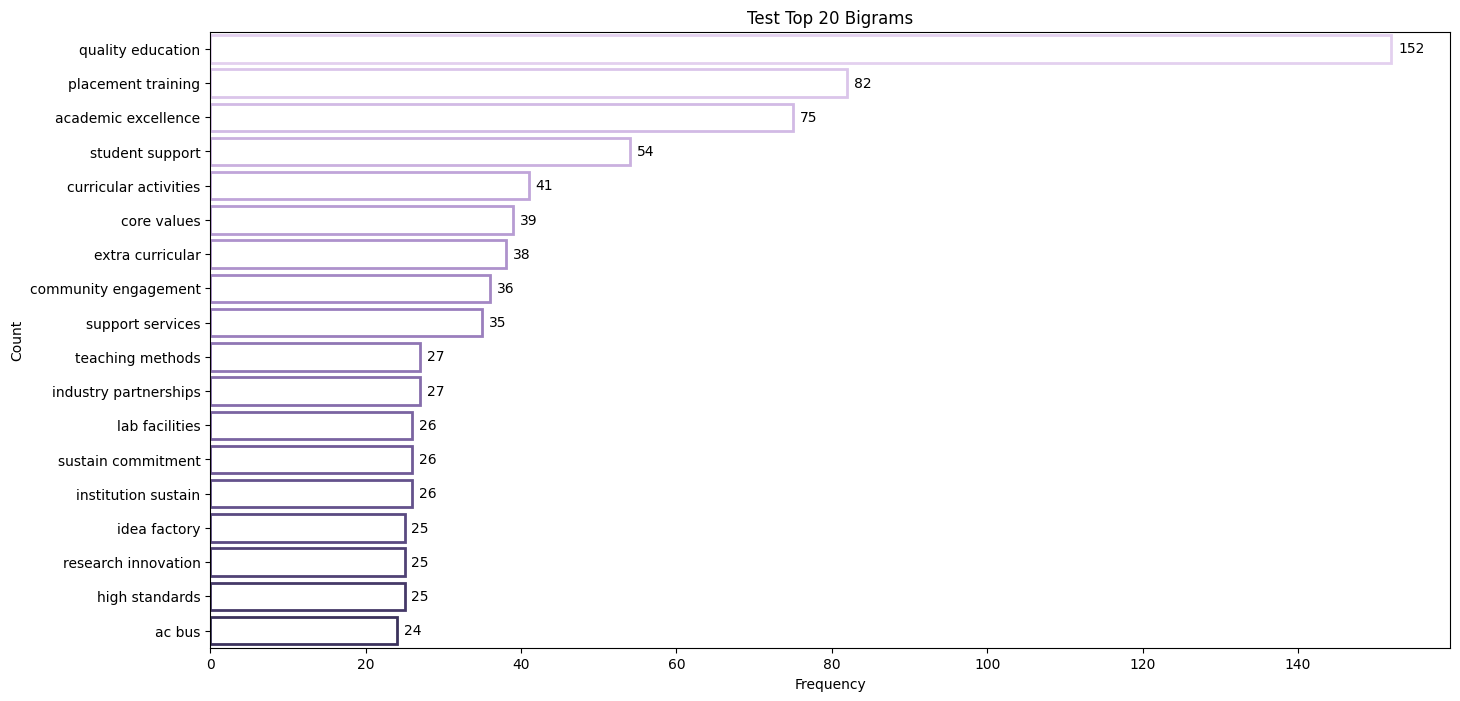

In [63]:
plot_top_n(out, title="Test Top 20 Bigrams")